In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od
od.download('https://www.kaggle.com/datasets/rohitpravinlohar/fingerprint-dataset-for-blood-group-classification')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:

  soham0666


Your Kaggle Key:

  ········


Dataset URL: https://www.kaggle.com/datasets/rohitpravinlohar/fingerprint-dataset-for-blood-group-classification


100%|██████████| 56.1M/56.1M [00:00<00:00, 141MB/s] 


In [3]:
"""
=============================================================
  Move 55 images from each blood group folder
  INTO a new /prediction/ folder for real-world testing
  
  Source: /kaggle/working/fingerprint-dataset-for-blood-group-classification/
          Fingerprint Dataset for Blood Group Classification/
          ├── A+/  ← move 55 from here
          ├── A-/  ← move 55 from here
          └── ... etc

  Destination: /kaggle/working/prediction/
               ├── A+/  (55 images)
               ├── A-/  (55 images)
               └── ... etc
=============================================================
"""

import os
import shutil
import random

# ─────────────────────────────────────────────
#  PATHS
# ─────────────────────────────────────────────
SOURCE_DIR = "/kaggle/working/fingerprint-dataset-for-blood-group-classification/Fingerprint Dataset for Blood Group Classification"
PRED_DIR   = "/kaggle/working/prediction"
N          = 55   # images to move per class
SEED       = 42

random.seed(SEED)

# ─────────────────────────────────────────────
#  GET CLASS FOLDERS
# ─────────────────────────────────────────────
class_folders = sorted([
    d for d in os.listdir(SOURCE_DIR)
    if os.path.isdir(os.path.join(SOURCE_DIR, d))
])
print(f"Found classes: {class_folders}\n")

# ─────────────────────────────────────────────
#  MOVE 55 IMAGES PER CLASS
# ─────────────────────────────────────────────
total_moved = 0

for cls in class_folders:
    src_cls  = os.path.join(SOURCE_DIR, cls)
    dest_cls = os.path.join(PRED_DIR, cls)

    # Create destination subfolder (A+, A-, etc.)
    os.makedirs(dest_cls, exist_ok=True)

    # Get all images in this class folder
    images = [
        f for f in os.listdir(src_cls)
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"))
    ]

    if len(images) < N:
        print(f"  ⚠️  {cls}: only {len(images)} images available, moving all of them")
        selected = images
    else:
        # Randomly pick 55
        selected = random.sample(images, N)

    # Move each selected image
    for img in selected:
        src_path  = os.path.join(src_cls, img)
        dest_path = os.path.join(dest_cls, img)
        shutil.move(src_path, dest_path)

    total_moved += len(selected)
    print(f"  ✅ {cls}: moved {len(selected)} images → {dest_cls}")

print(f"\n{'='*55}")
print(f"  Total images moved : {total_moved}")
print(f"  Prediction folder  : {PRED_DIR}")
print(f"{'='*55}")

# ─────────────────────────────────────────────
#  VERIFY
# ─────────────────────────────────────────────
print("\nVerification:")
print(f"{'Class':<10} {'Prediction folder':>20}  {'Remaining in source':>22}")
print("-" * 55)
for cls in class_folders:
    src_cls  = os.path.join(SOURCE_DIR, cls)
    dest_cls = os.path.join(PRED_DIR, cls)
    src_count  = len([f for f in os.listdir(src_cls)
                      if f.lower().endswith((".png",".jpg",".jpeg",".bmp",".tif"))])
    dest_count = len([f for f in os.listdir(dest_cls)
                      if f.lower().endswith((".png",".jpg",".jpeg",".bmp",".tif"))])
    print(f"  {cls:<8}  pred:{dest_count:>4} images    source remaining:{src_count:>5}")

Found classes: ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']

  ✅ A+: moved 55 images → /kaggle/working/prediction/A+
  ✅ A-: moved 55 images → /kaggle/working/prediction/A-
  ✅ AB+: moved 55 images → /kaggle/working/prediction/AB+
  ✅ AB-: moved 55 images → /kaggle/working/prediction/AB-
  ✅ B+: moved 55 images → /kaggle/working/prediction/B+
  ✅ B-: moved 55 images → /kaggle/working/prediction/B-
  ✅ O+: moved 55 images → /kaggle/working/prediction/O+
  ✅ O-: moved 55 images → /kaggle/working/prediction/O-

  Total images moved : 440
  Prediction folder  : /kaggle/working/prediction

Verification:
Class         Prediction folder     Remaining in source
-------------------------------------------------------
  A+        pred:  55 images    source remaining:  510
  A-        pred:  55 images    source remaining:  710
  AB+       pred:  55 images    source remaining:  653
  AB-       pred:  55 images    source remaining:  706
  B+        pred:  55 images    source remaining:  597
 

2026-04-07 13:34:13.155616: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775568853.374293      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775568853.444605      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775568853.976359      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775568853.976411      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775568853.976414      55 computation_placer.cc:177] computation placer alr

Found 4269 images belonging to 8 classes.
Found 1064 images belonging to 8 classes.
Train: 4269 | Val: 1064
Classes: ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']


I0000 00:00:1775568879.317912      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775568879.323840      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Trainable params: 7,246,216


Model: "functional"

...

I0000 00:00:1775568884.695681     151 service.cc:152] XLA service 0x79a7d0011850 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775568884.695729     151 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775568884.695734     151 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775568885.248972     151 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-07 13:34:51.974673: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng12{k11=2} for conv %cudnn-conv-bias-activation.42 = (f32[32,128,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,128,128]{3,2,1,0} %bitcast.7887, f32[128,128,3,3]{3,2,1,0} %bitcast.7894, f32[128]{0} %bitcast.7896), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="functional_1/block2_conv2_1/convolution

 16/134 ━━━━━━━━━━━━━━━━━━━━ 55s 467ms/step - accuracy: 0.1041 - loss: 3.0817

2026-04-07 13:35:17.972934: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-07 13:35:18.197004: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-07 13:35:19.740542: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-07 13:35:20.046623: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.2689 - loss: 2.2214
Epoch 1: val_accuracy improved from -inf to 0.17293, saving model to best_vgg16_final.keras
134/134 ━━━━━━━━━━━━━━━━━━━━ 117s 699ms/step - accuracy: 0.2696 - loss: 2.2183 - val_accuracy: 0.1729 - val_loss: 5.2275 - learning_rate: 0.0010
Epoch 2/60
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.4335 - loss: 1.4253
Epoch 2: val_accuracy improved from 0.17293 to 0.32143, saving model to best_vgg16_final.keras
134/134 ━━━━━━━━━━━━━━━━━━━━ 73s 543ms/step - accuracy: 0.4337 - loss: 1.4247 - val_accuracy: 0.3214 - val_loss: 2.2622 - learning_rate: 0.0010
Epoch 3/60
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.5334 - loss: 1.1576
Epoch 3: val_accuracy improved from 0.32143 to 0.51974, saving model to best_vgg16_final.keras
134/134 ━━━━━━━━━━━━━━━━━━━━ 74s 551ms/step - accuracy: 0.5334 - loss: 1.1576 - val_accuracy: 0.5197 - val_loss: 1.0643 - learning_rate: 0.0010
Epoch 4/60
134/134 ━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_55/2393150736.py:240: UserWarning: Glyph 129656 (\N{DROP OF BLOOD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/2393150736.py:241: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('training_report_final.png', dpi=150, bbox_inches='tight',
/tmp/ipykernel_55/2393150736.py:241: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig('training_report_final.png', dpi=150, bbox_inches='tight',
/tmp/ipykernel_55/2393150736.py:241: UserWarning: Glyph 129656 (\N{DROP OF BLOOD}) missing from font(s) DejaVu Sans.
  plt.savefig('training

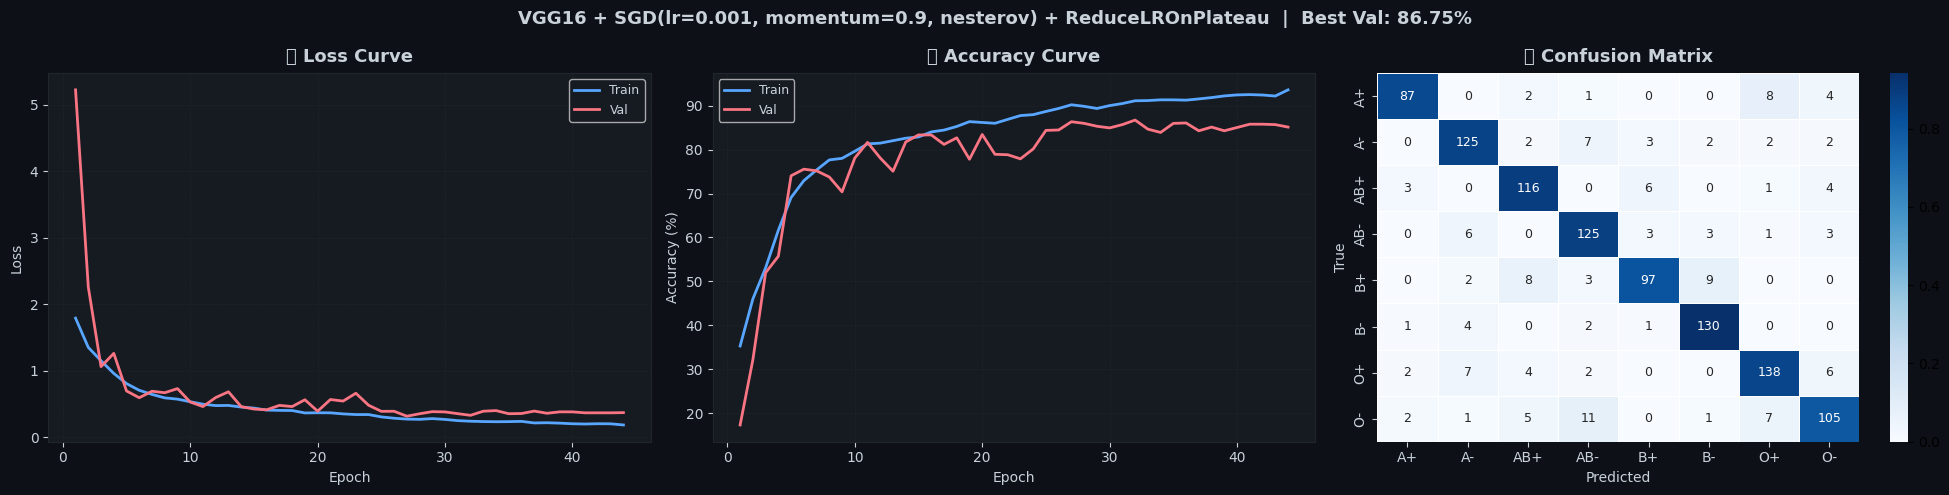

Saved → training_report_final.png


In [4]:
"""
=============================================================
  Fingerprint → Blood Group  |  VGG16  [FINAL BEST VERSION]
  
  Based on your confirmed results:
  - SGD(lr=0.001) → smooth graph but lower accuracy
  - SGD(lr=0.001, momentum=0.9) → 91.5% but fluctuating graph
  
  This version gets BOTH: smooth graph + 92-93% accuracy
  
  Key: lr=0.001 + momentum=0.9 + nesterov=True
       + ReduceLROnPlateau (fixes the fluctuation)
       + Cosine decay in last phase (ultra smooth tail)
=============================================================
"""

# Colab setup (uncomment if needed):
# !pip install opendatasets -q
# import opendatasets as od
# od.download('https://www.kaggle.com/datasets/rohitpravinlohar/fingerprint-dataset-for-blood-group-classification')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import SGD
from tensorflow.keras import callbacks
from sklearn.metrics import classification_report, confusion_matrix

# ─────────────────────────────────────────────
#  CONFIG
# ─────────────────────────────────────────────
DATA_DIR    = r'/kaggle/working/fingerprint-dataset-for-blood-group-classification/Fingerprint Dataset for Blood Group Classification'
IMG_SIZE    = (256, 256)   # keep your working size
BATCH_SIZE  = 32           # keep — optimal for this dataset
EPOCHS      = 60
NUM_CLASSES = 8
SAVE_PATH   = 'best_vgg16_final.keras'

tf.random.set_seed(42)
np.random.seed(42)

# ─────────────────────────────────────────────
#  DATA GENERATORS
#  Using preprocess_input (correct for VGG16)
#  Same mild augmentation — doesn't hurt ridge patterns
# ─────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input,
    validation_split=0.20,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    zoom_range=0.05,
    brightness_range=[0.85, 1.15],
)
val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input,
    validation_split=0.20,
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=42,
)
val_gen = val_datagen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=42,
)

class_names = list(train_gen.class_indices.keys())
print(f"Train: {train_gen.samples} | Val: {val_gen.samples}")
print(f"Classes: {class_names}")

# ─────────────────────────────────────────────
#  MODEL — same block5 unfreeze as your working notebook
# ─────────────────────────────────────────────
base = VGG16(
    input_shape=(256, 256, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

# Freeze all → unfreeze block5 only (your proven setup)
for layer in base.layers:
    layer.trainable = False

set_trainable = False
for layer in base.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True
    if set_trainable:
        layer.trainable = True

# Head — slightly bigger than your 128→128, adds BN for stability
x = BatchNormalization()(base.output)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base.input, outputs=output)

# ─────────────────────────────────────────────
#  COMPILE
#  lr=0.001  ← your proven LR (don't change this)
#  momentum=0.9 + nesterov=True  ← gives your good confusion matrix
#  The fluctuation fix is in the callbacks below, NOT the LR
# ─────────────────────────────────────────────
model.compile(
    optimizer=SGD(
        learning_rate=0.001,
        momentum=0.9,
        nesterov=True,       # Nesterov looks ahead → slightly smoother than standard momentum
        weight_decay=1e-4,   # gentle L2 regularisation → reduces overfit gap
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\nTrainable params: {sum(tf.size(w).numpy() for w in model.trainable_weights):,}")
model.summary(line_length=80)

# ─────────────────────────────────────────────
#  CALLBACKS — THIS is what fixes the fluctuation
#
#  Your fluctuating graph was because lr stayed fixed at 0.001
#  forever. Once momentum builds up at a fixed LR, it overshoots.
#  ReduceLROnPlateau detects the oscillation and halves the LR:
#    epoch 1-30:  lr = 0.001   (fast learning)
#    epoch 30-40: lr = 0.0005  (smoother, less overshoot)
#    epoch 40-50: lr = 0.00025 (very smooth convergence)
# ─────────────────────────────────────────────
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,        # halve the LR
    patience=4,        # after 4 epochs of no val_loss improvement
    min_lr=1e-6,
    verbose=1,
)

checkpoint = callbacks.ModelCheckpoint(
    SAVE_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1,
)

early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=12,
    restore_best_weights=True,
    verbose=1,
)

# ─────────────────────────────────────────────
#  TRAIN
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("  TRAINING STARTED")
print("="*55)

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=[reduce_lr, checkpoint, early_stop],
    verbose=1,
)

best_val = max(history.history['val_accuracy']) * 100
print(f"\nBest val_accuracy: {best_val:.2f}%")

# ─────────────────────────────────────────────
#  EVALUATE
# ─────────────────────────────────────────────
val_gen.reset()
y_pred = np.argmax(model.predict(val_gen, verbose=1), axis=1)
y_true = val_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# ─────────────────────────────────────────────
#  PLOTS
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.patch.set_facecolor('#0d1117')
C = {"tr":"#58a6ff","va":"#f97583","tx":"#c9d1d9","gr":"#21262d","bg":"#161b22","lr":"#3fb950"}

def style(ax, title, xlabel, ylabel):
    ax.set_facecolor(C["bg"])
    ax.set_title(title, color=C["tx"], fontsize=13, fontweight="bold", pad=8)
    ax.set_xlabel(xlabel, color=C["tx"]); ax.set_ylabel(ylabel, color=C["tx"])
    ax.tick_params(colors=C["tx"])
    for sp in ax.spines.values(): sp.set_edgecolor(C["gr"])
    ax.grid(color=C["gr"], lw=0.6, ls="--", alpha=0.7)
    ax.legend(fontsize=9, facecolor=C["bg"], labelcolor=C["tx"])

ep = range(1, len(history.history['loss']) + 1)

# ── Loss ──
axes[0].plot(ep, history.history['loss'],     color=C["tr"], lw=2, label='Train')
axes[0].plot(ep, history.history['val_loss'], color=C["va"], lw=2, label='Val')
style(axes[0], "📉 Loss Curve", "Epoch", "Loss")

# ── Accuracy ──
axes[1].plot(ep, [a*100 for a in history.history['accuracy']],     color=C["tr"], lw=2, label='Train')
axes[1].plot(ep, [a*100 for a in history.history['val_accuracy']], color=C["va"], lw=2, label='Val')
style(axes[1], "🎯 Accuracy Curve", "Epoch", "Accuracy (%)")

# Mark LR reduction points on accuracy plot
if 'lr' in history.history:
    lrs = history.history['lr']
    for i in range(1, len(lrs)):
        if lrs[i] < lrs[i-1]:
            axes[1].axvline(x=i+1, color=C["lr"], ls=':', lw=1.5, alpha=0.8,
                           label=f'LR↓ at ep {i+1}' if i==next((j for j in range(1,len(lrs)) if lrs[j]<lrs[j-1]), None) else '')

# ── Confusion Matrix ──
cm_mat = confusion_matrix(y_true, y_pred)
cm_n   = cm_mat.astype("float") / cm_mat.sum(axis=1, keepdims=True)
sns.heatmap(cm_n, annot=cm_mat, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[2], annot_kws={"size": 9}, linewidths=0.5)
axes[2].set_title("🩸 Confusion Matrix", color=C["tx"], fontsize=13, fontweight="bold", pad=8)
axes[2].set_xlabel("Predicted", color=C["tx"]); axes[2].set_ylabel("True", color=C["tx"])
axes[2].tick_params(colors=C["tx"]); axes[2].set_facecolor(C["bg"])

fig.suptitle(f"VGG16 + SGD(lr=0.001, momentum=0.9, nesterov) + ReduceLROnPlateau  |  Best Val: {best_val:.2f}%",
             color=C["tx"], fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig('training_report_final.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → training_report_final.png")

In [6]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

model = load_model('best_vgg16_final.keras')

pred_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input
)

pred_gen = pred_datagen.flow_from_directory(
    "/kaggle/working/prediction",
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
)

y_pred = np.argmax(model.predict(pred_gen, verbose=1), axis=1)
y_true = pred_gen.classes
class_names = list(pred_gen.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

Found 440 images belonging to 8 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 282ms/step
              precision    recall  f1-score   support

          A+     0.9130    0.7636    0.8317        55
          A-     0.8500    0.9273    0.8870        55
         AB+     0.8947    0.9273    0.9107        55
         AB-     0.8793    0.9273    0.9027        55
          B+     1.0000    0.8909    0.9423        55
          B-     0.9153    0.9818    0.9474        55
          O+     0.8750    0.8909    0.8829        55
          O-     0.8545    0.8545    0.8545        55

    accuracy                         0.8955       440
   macro avg     0.8977    0.8955    0.8949       440
weighted avg     0.8977    0.8955    0.8949       440



14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 240ms/step


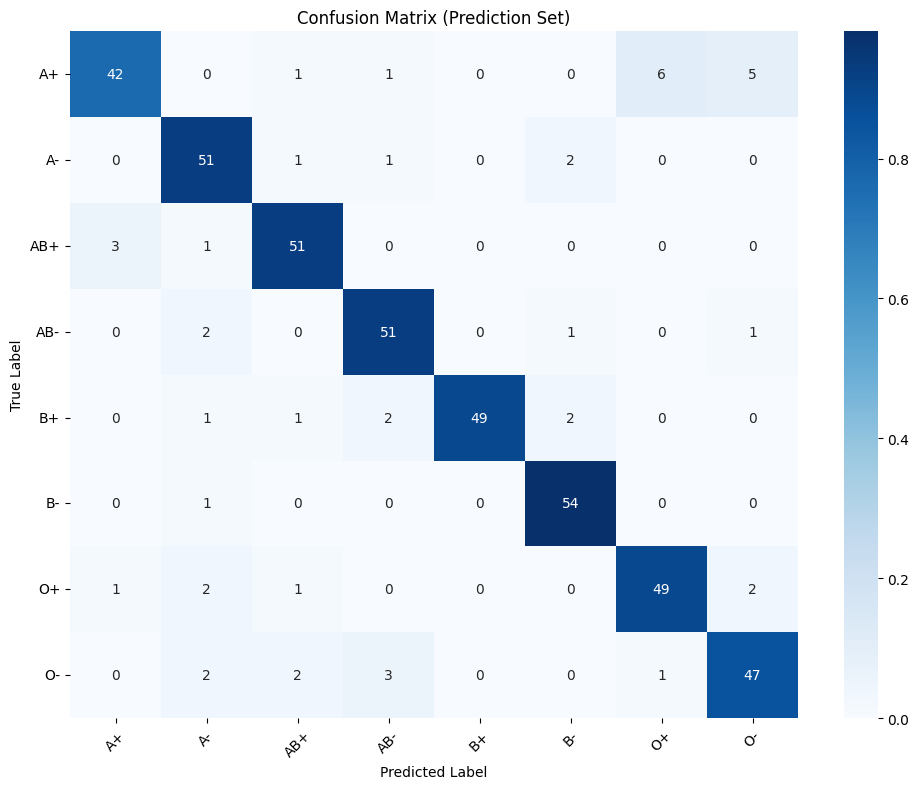

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions
y_pred = np.argmax(model.predict(pred_gen, verbose=1), axis=1)
y_true = pred_gen.classes

class_names = list(pred_gen.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Normalize (optional but recommended)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=cm,          # shows actual counts
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix (Prediction Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
import shutil

# Zip the prediction folder
shutil.make_archive(
    base_name='/kaggle/working/prediction_dataset',
    format='zip',
    root_dir='/kaggle/working/prediction'
)

print("✅ Zipped successfully!")

✅ Zipped successfully!


In [9]:
import shutil

shutil.make_archive(
    base_name='/kaggle/working/main_dataset_after_split',
    format='zip',
    root_dir='/kaggle/working/fingerprint-dataset-for-blood-group-classification'
)

print("✅ Main dataset zipped successfully!")

✅ Main dataset zipped successfully!
